# Chapter 2: End-to-End Machine Learning Project
## Predicting House Prices: The Ames Iowa Dataset

This notebook walks through a complete machine learning pipeline from scratch, following the exact steps covered in Chapter 2 of the book. The dataset is the **Ames Iowa Housing dataset**, with 79 features describing almost every aspect of residential homes sold in Ames, Iowa between 2006 and 2010.

Our goal is simple: **predict the final sale price of a house** given its characteristics. This is a regression problem.

We will go through every single step: problem analysis, EDA, splitting, feature engineering, cleaning, scaling, pipeline, training, cross-validation, hyperparameter tuning, and final evaluation.

---
## OPEN THIS NOTEBOOK IN COLAB, AND TRY TUN IT
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LeonardoCofone/The-AI-Handbook/blob/main/chapter_2_Machine_Learning.ipynb)

---
## 1. Setup & Imports

In [2]:
%pip install numpy pandas matplotlib seaborn scikit-learn scipy joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)

print('All imports successful.')

All imports successful.


---
## 2. Problem Analysis

Before writing a single line of modeling code, we need to understand what we are dealing with.

- **Type of learning:** Supervised, we have labeled examples (houses with known sale prices).
- **Task type:** Regression, we are predicting a continuous numeric value (SalePrice in dollars).
- **Batch vs. online:** Batch learning, we train on a fixed dataset.
- **Success metric:** We will use **RMSE** (Root Mean Squared Error) as our primary metric. It penalizes large errors more than MAE, which is appropriate here since a prediction off by $100,000 is much worse than one off by $10,000.

---
## 3. Download & Load the Data

The Ames dataset is available directly from OpenML, no Kaggle account needed.

In [4]:
from sklearn.datasets import fetch_openml

# Fetch the Ames Iowa Housing dataset from OpenML
ames_raw = fetch_openml(name='house_prices', as_frame=True, parser='auto')

df = ames_raw.frame.copy()

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')

Dataset loaded: 1460 rows, 81 columns


---
## 4. Exploratory Data Analysis (EDA)

The first thing to do is not build a model, it's *look at the data*. This phase is called EDA (Exploratory Data Analysis) and it tells you what you are actually working with before you do anything else.

In [5]:
# First 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,'Wd Sdng','Wd Shng',...,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
# General info: types, nulls
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [8]:
# Descriptive statistics on all numeric columns
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [9]:
# Dataset shape
print('Shape:', df.shape)

# Count nulls per column (only show columns that have at least one null)
null_counts = df.isnull().sum()
print('\nColumns with missing values:')
print(null_counts[null_counts > 0].sort_values(ascending=False))

Shape: (1460, 81)

Columns with missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageCond        81
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrType         8
MasVnrArea         8
Electrical         1
dtype: int64


In [10]:
# Check for duplicates
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Duplicates removed. New shape:', df.shape)

Duplicate rows: 0
Duplicates removed. New shape: (1460, 81)


### Target distribution: SalePrice

Let's look at our target variable. A heavy right tail is very common in housing prices, a few luxury homes pull the distribution upward.

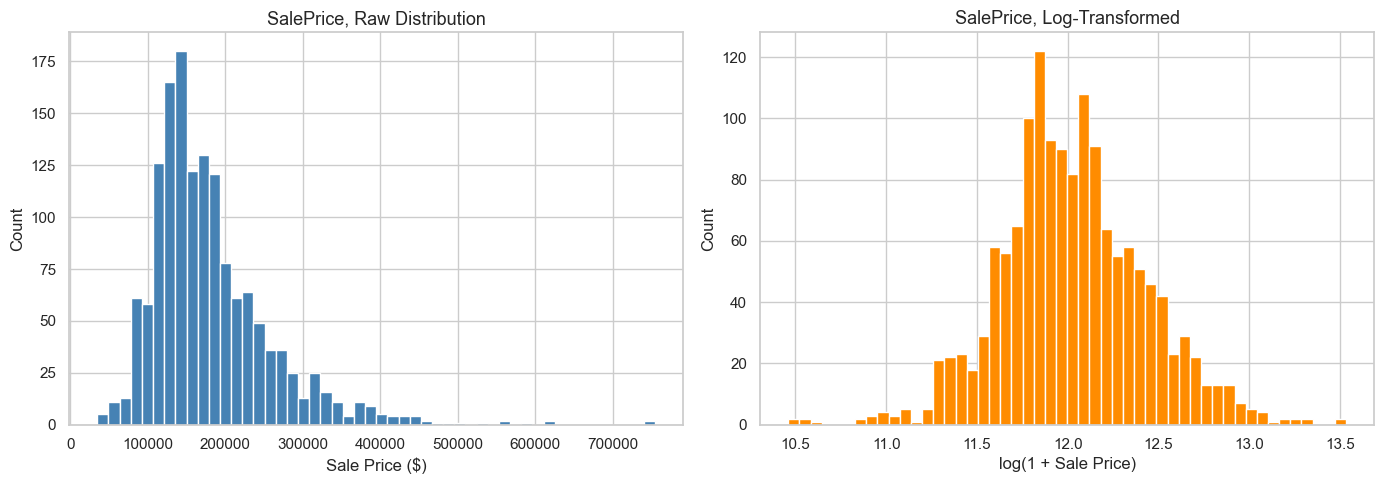

Raw , Skewness: 1.883
Log , Skewness: 0.121


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw SalePrice
axes[0].hist(df['SalePrice'].astype(float), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice, Raw Distribution', fontsize=13)
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')

# Log-transformed SalePrice
axes[1].hist(np.log1p(df['SalePrice'].astype(float)), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('SalePrice, Log-Transformed', fontsize=13)
axes[1].set_xlabel('log(1 + Sale Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Raw , Skewness: {df["SalePrice"].astype(float).skew():.3f}')
print(f'Log , Skewness: {np.log1p(df["SalePrice"].astype(float)).skew():.3f}')

The raw distribution has a strong right tail, a classic **heavy-tail** problem. After the log transformation, the distribution is much more symmetric. This is why we will apply `log1p` to the target before training and `expm1` to convert predictions back.

### Correlation heatmap

Let's look at which numeric features are most correlated with SalePrice, this is the first step of feature selection.

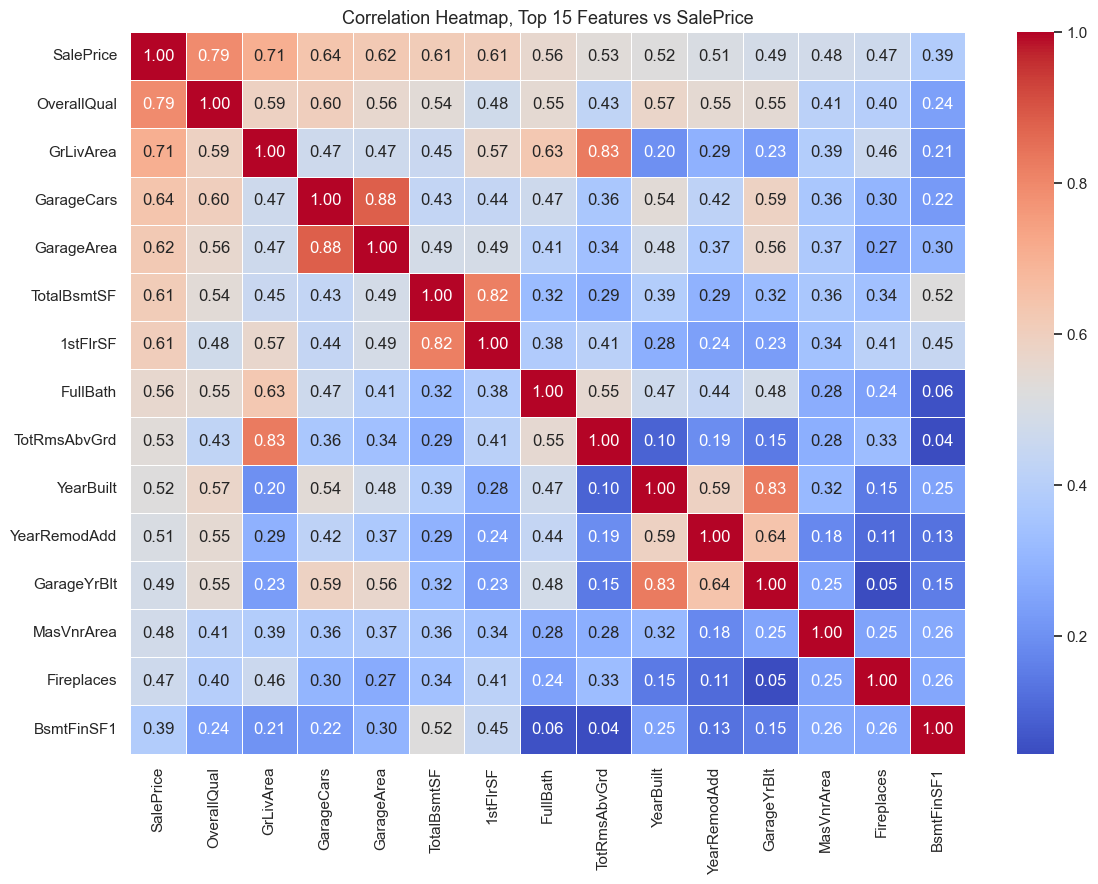

In [12]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_num = df[numeric_cols].copy()

# Top 15 features most correlated with SalePrice
corr_with_target = df_num.corr()['SalePrice'].abs().sort_values(ascending=False)
top_features = corr_with_target.head(15).index.tolist()

correlation_matrix = df_num[top_features].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Heatmap, Top 15 Features vs SalePrice', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Top 10 numeric features most correlated with SalePrice
print('Top 10 features correlated with SalePrice:')
print(corr_with_target.head(11))  # 11 because SalePrice itself is first

Top 10 features correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


### Scatter plots: top features vs SalePrice

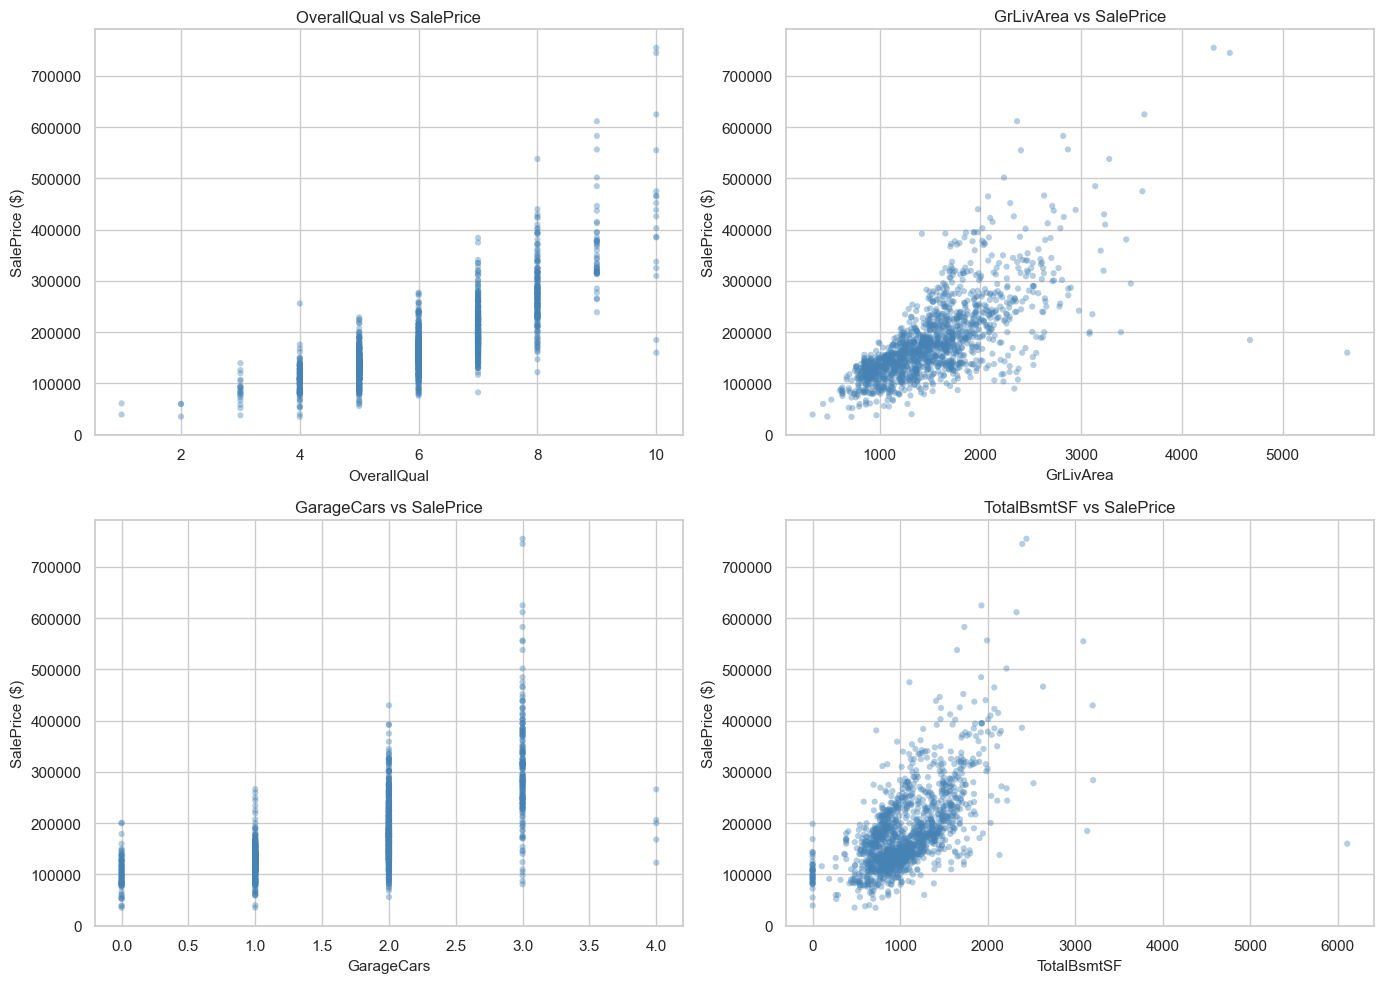

In [14]:
top_scatter = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_scatter):
    axes[i].scatter(
        df[feat].astype(float),
        df['SalePrice'].astype(float),
        alpha=0.4,
        color='steelblue',
        edgecolors='none',
        s=20
    )
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel('SalePrice ($)', fontsize=11)
    axes[i].set_title(f'{feat} vs SalePrice', fontsize=12)

plt.tight_layout()
plt.show()

---
## 5. Split the Dataset

Before touching the data in any other way, we separate the test set and put it aside. This is one of the most important principles in ML: **the test set must never influence any decision made during development**.

In [15]:
# Separate features and target
X = df.drop('SalePrice', axis=1).copy()
y = np.log1p(df['SalePrice'].astype(float))  # log-transform the target

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set:   {X_train.shape[0]} rows')
print(f'Test set:       {X_test.shape[0]} rows')

Training set:   1168 rows
Test set:       292 rows


---
## 6. Feature Engineering

Before cleaning, it's worth thinking about what we can *create* from what we already have. A well-crafted feature often does more for a model than any algorithm tweak.

We will create a few intuitive new features:
- **TotalSF**: total square footage of the house (basement + first floor + second floor)
- **HouseAge**: how old the house was when it was sold
- **RemodelAge**: how many years since the last remodel at time of sale
- **TotalBathrooms**: a unified count of all bathrooms

In [16]:
def add_features(X):
    X = X.copy()

    # Total square footage
    X['TotalSF'] = (
        X['TotalBsmtSF'].astype(float).fillna(0)
        + X['1stFlrSF'].astype(float).fillna(0)
        + X['2ndFlrSF'].astype(float).fillna(0)
    )

    # House age at time of sale
    X['HouseAge'] = X['YrSold'].astype(float) - X['YearBuilt'].astype(float)

    # Years since last remodel at time of sale
    X['RemodelAge'] = X['YrSold'].astype(float) - X['YearRemodAdd'].astype(float)

    # Total bathrooms (full baths count 1, half baths count 0.5)
    X['TotalBathrooms'] = (
        X['FullBath'].astype(float).fillna(0)
        + 0.5 * X['HalfBath'].astype(float).fillna(0)
        + X['BsmtFullBath'].astype(float).fillna(0)
        + 0.5 * X['BsmtHalfBath'].astype(float).fillna(0)
    )

    return X


X_train = add_features(X_train)
X_test  = add_features(X_test)

print('New features added:', ['TotalSF', 'HouseAge', 'RemodelAge', 'TotalBathrooms'])
print('New training shape:', X_train.shape)

New features added: ['TotalSF', 'HouseAge', 'RemodelAge', 'TotalBathrooms']
New training shape: (1168, 84)


---
## 7. Build the Full Pipeline

Now we put everything together: imputation, encoding, and scaling, applied to the right columns, all inside a single `ColumnTransformer`. This way we can never forget a step, and the code is clean and reusable.

The columns with heavy-tail distributions get a log transformation before scaling. Categorical columns get imputed with the most frequent value and then one-hot encoded. Numeric columns get median imputation and standard scaling.

In [17]:
# Identify column groups after feature engineering
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Columns with heavy-tail distributions that benefit from log transform
log_cols = ['GrLivArea', 'LotArea', 'TotalBsmtSF', 'TotalSF', '1stFlrSF']
log_cols = [c for c in log_cols if c in num_cols]  # keep only those present

# Remaining numeric columns (exclude log_cols)
reg_num_cols = [c for c in num_cols if c not in log_cols]

print(f'Categorical columns:   {len(cat_cols)}')
print(f'Log-transform columns: {len(log_cols)}')
print(f'Regular numeric cols:  {len(reg_num_cols)}')

Categorical columns:   43
Log-transform columns: 5
Regular numeric cols:  36


In [18]:
# Pipeline for columns with heavy-tail distributions
log_transformer = make_pipeline(
    SimpleImputer(strategy='median'),
    FunctionTransformer(np.log1p, feature_names_out='one-to-one'),
    StandardScaler()
)

# Pipeline for regular numeric columns
numeric_transformer = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

# Pipeline for categorical columns
categorical_transformer = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

# ColumnTransformer: routes each column group to its pipeline
preprocessor = ColumnTransformer([
    ('log',  log_transformer,         log_cols),
    ('num',  numeric_transformer,     reg_num_cols),
    ('cat',  categorical_transformer, cat_cols),
])

print('Preprocessor built successfully.')

Preprocessor built successfully.


---
## 8. Train the Model

We include the preprocessor directly inside the full pipeline so that training and preprocessing are one single operation. We start with a simple **Linear Regression** baseline, then try a **Random Forest**.

In [19]:
# --- Baseline: Linear Regression ---
lin_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

lin_pipeline.fit(X_train, y_train)

# Quick check on training set
train_preds_lin = lin_pipeline.predict(X_train)
train_rmse_lin = root_mean_squared_error(y_train, train_preds_lin)
print(f'Linear Regression, Training RMSE (log scale): {train_rmse_lin:.4f}')

Linear Regression, Training RMSE (log scale): 0.0878


In [ ]:
# --- Random Forest Regressor ---
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

train_preds_rf = rf_pipeline.predict(X_train)
train_rmse_rf = root_mean_squared_error(y_train, train_preds_rf)
print(f'Random Forest, Training RMSE (log scale): {train_rmse_rf:.4f}')

Random Forest    , Training RMSE (log scale): 0.0523


A very low training RMSE on the Random Forest is expected, trees can memorize training data. That's exactly why we need cross-validation to get a reliable estimate.

---
## 9. Cross-Validation

Cross-validation gives us a much more reliable performance estimate than a single train/validation split. The training set is divided into `cv` folds; the model is trained and evaluated `cv` times, each time on a different fold. We then average the results.

In [21]:
from sklearn.model_selection import cross_val_score

# Linear Regression CV
lin_rmses = -cross_val_score(
    lin_pipeline, X_train, y_train,
    scoring='neg_root_mean_squared_error', cv=5
)

print('Linear Regression, Cross-Validation RMSE (log scale):')
print(pd.Series(lin_rmses).describe().round(4))

Linear Regression, Cross-Validation RMSE (log scale):
count    5.0000
mean     0.1503
std      0.0168
min      0.1305
25%      0.1359
50%      0.1558
75%      0.1582
max      0.1711
dtype: float64


In [22]:
# Random Forest CV
rf_rmses = -cross_val_score(
    rf_pipeline, X_train, y_train,
    scoring='neg_root_mean_squared_error', cv=5
)

print('Random Forest, Cross-Validation RMSE (log scale):')
print(pd.Series(rf_rmses).describe().round(4))

Random Forest, Cross-Validation RMSE (log scale):
count    5.0000
mean     0.1435
std      0.0219
min      0.1191
25%      0.1297
50%      0.1362
75%      0.1621
max      0.1704
dtype: float64


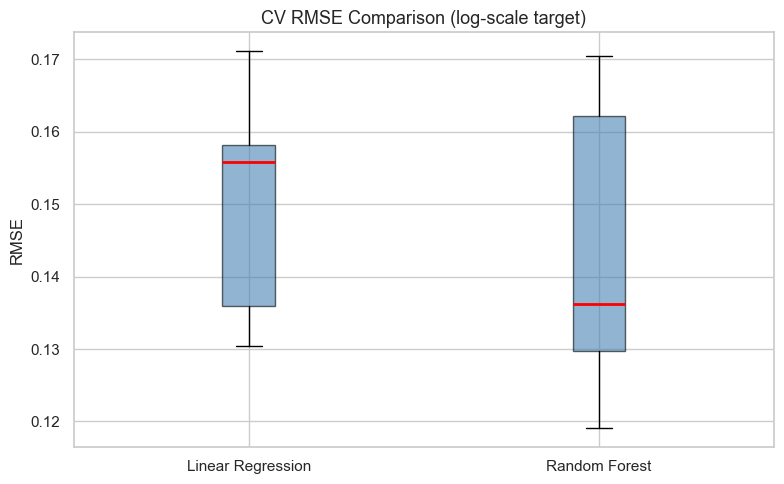

In [23]:
# Visual comparison
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    [lin_rmses, rf_rmses],
    labels=['Linear Regression', 'Random Forest'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2)
)

ax.set_title('CV RMSE Comparison (log-scale target)', fontsize=13)
ax.set_ylabel('RMSE')
plt.tight_layout()
plt.show()

The Random Forest clearly outperforms the linear model. We move forward with it for hyperparameter tuning.

---
## 10. Hyperparameter Tuning

The Random Forest has several hyperparameters we can tune. Instead of Grid Search (which tries every combination exhaustively), we use **Randomized Search**, it samples random combinations from a defined distribution. Much faster, and usually finds results just as good.

Remember: hyperparameters are set *before* training. The model learns its *parameters* during training. Finding the best hyperparameters is called tuning.

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
    'model__n_estimators':  randint(low=50,  high=300),
    'model__max_features':  randint(low=5,   high=30),
    'model__max_depth':     randint(low=5,   high=30),
    'model__min_samples_leaf': randint(low=1, high=10),
}

rnd_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distribs,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rnd_search.fit(X_train, y_train)

print('\nBest hyperparameters found:')
print(rnd_search.best_params_)
print(f'\nBest CV RMSE: {-rnd_search.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best hyperparameters found:
{'model__max_depth': 13, 'model__max_features': 25, 'model__min_samples_leaf': 2, 'model__n_estimators': 133}

Best CV RMSE: 0.1436


In [ ]:
# Best model (already fitted with best params)
#This cell may take some minutes to run
final_model = rnd_search.best_estimator_

# Top 10 results
cv_results = pd.DataFrame(rnd_search.cv_results_)
top10 = cv_results[['params', 'mean_test_score']].copy()
top10['mean_test_score'] = -top10['mean_test_score']
top10 = top10.sort_values('mean_test_score').head(10)
print('Top 10 parameter combinations by RMSE:')
top10

Top 10 parameter combinations by RMSE:


,params,mean_test_score
12,"{'model__max_depth': 13, 'model__max_features'...",0.143606
4,"{'model__max_depth': 26, 'model__max_features'...",0.143739
11,"{'model__max_depth': 29, 'model__max_features'...",0.145935
7,"{'model__max_depth': 29, 'model__max_features'...",0.146549
17,"{'model__max_depth': 22, 'model__max_features'...",0.148126
16,"{'model__max_depth': 10, 'model__max_features'...",0.148320
14,"{'model__max_depth': 7, 'model__max_features':...",0.154299
10,"{'model__max_depth': 13, 'model__max_features'...",0.154469
19,"{'model__max_depth': 27, 'model__max_features'...",0.154951
5,"{'model__max_depth': 16, 'model__max_features'...",0.156066


---
## 11. Final Evaluation on the Test Set

This is the moment we have been saving the test set for. We use it **once, and only once**, after all decisions have been made. The result is our honest estimate of real-world performance.

In [26]:
final_predictions_log = final_model.predict(X_test)

# RMSE in log scale
final_rmse_log = root_mean_squared_error(y_test, final_predictions_log)
print(f'Final RMSE (log scale):    {final_rmse_log:.4f}')

# Convert back to original dollar scale
final_predictions_dollars = np.expm1(final_predictions_log)
y_test_dollars = np.expm1(y_test)

final_rmse_dollars = root_mean_squared_error(y_test_dollars, final_predictions_dollars)
print(f'Final RMSE (dollar scale): ${final_rmse_dollars:,.0f}')

Final RMSE (log scale):    0.1550
Final RMSE (dollar scale): $33,688


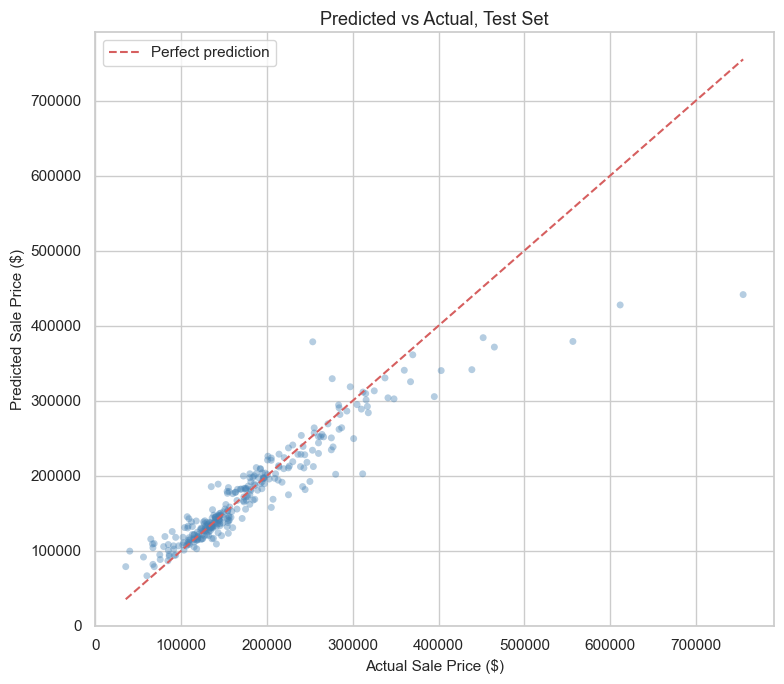

In [28]:
# Predicted vs Actual scatter plot
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    y_test_dollars,
    final_predictions_dollars,
    alpha=0.4,
    color='steelblue',
    edgecolors='none',
    s=25
)

# Perfect prediction line
min_val = min(y_test_dollars.min(), final_predictions_dollars.min())
max_val = max(y_test_dollars.max(), final_predictions_dollars.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Actual Sale Price ($)', fontsize=11)
ax.set_ylabel('Predicted Sale Price ($)', fontsize=11)
ax.set_title('Predicted vs Actual, Test Set', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

---
## 12. Save and Reload the Model

Training takes time and resources. We save the final model to disk so we can reload it anytime and predict on new data without retraining. Since the preprocessing pipeline is built in, calling `.predict()` on the reloaded model handles everything automatically.

In [29]:
import joblib

# Save
joblib.dump(final_model, 'ames_housing_model.pkl')
print('Model saved to ames_housing_model.pkl')

# Reload
reloaded_model = joblib.load('ames_housing_model.pkl')

# Test on a few examples from the test set
sample = X_test.iloc[:5]
sample_preds = np.expm1(reloaded_model.predict(sample))
sample_actuals = np.expm1(y_test.iloc[:5])

comparison = pd.DataFrame({
    'Actual ($)':    sample_actuals.values.round(0).astype(int),
    'Predicted ($)': sample_preds.round(0).astype(int),
    'Error ($)':     (sample_preds - sample_actuals.values).round(0).astype(int)
})

print('\nSample predictions vs actuals:')
print(comparison)

Model saved to ames_housing_model.pkl

Sample predictions vs actuals:
   Actual ($)  Predicted ($)  Error ($)
0      154500         137457     -17043
1      325000         313113     -11887
2      115000         111360      -3640
3      159000         152351      -6649
4      315500         301058     -14442


---
## Summary

Here is every step we covered in this notebook, in order:

1. **Problem analysis**, regression, supervised learning, RMSE as the metric.
2. **Load data**, Ames Iowa Housing via OpenML (no account needed).
3. **EDA**, `.head()`, `.info()`, `.describe()`, null counts, duplicate check, target distribution, correlation heatmap.
4. **Split the dataset**, 80/20 train/test split, test set locked away immediately. Target log-transformed to handle heavy-tail distribution.
5. **Feature engineering**, TotalSF, HouseAge, RemodelAge, TotalBathrooms.
6. **Full pipeline**, `ColumnTransformer` with separate pipelines for log-columns, numeric columns, and categorical columns.
7. **Train**, Linear Regression baseline, then Random Forest.
8. **Cross-validation**, 5-fold CV to compare models reliably.
9. **Hyperparameter tuning**, Randomized Search over n_estimators, max_features, max_depth, min_samples_leaf.
10. **Final evaluation**, test set used once, RMSE in both log scale and dollar scale.
11. **Save / reload**, `joblib.dump` / `joblib.load` with the full pipeline included.